# AQI Predictor - Exploratory Data Analysis

Loads feature rows from the MongoDB feature store and explores trends, distributions, missing data, and correlations.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from pymongo import MongoClient

sys.path.append(os.path.abspath(os.path.join("..", "..")))
load_dotenv(os.path.join("..", "..", ".env"))

sns.set_theme(style="whitegrid")

In [2]:
client = MongoClient(os.getenv("MONGODB_URI"))
db = client[os.getenv("MONGODB_DB_NAME", "aqi_predictor")]

df = pd.DataFrame(list(db["aqi_features"].find({}, {"_id": 0})))
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)

print(df.shape)
df.head()

(696, 18)


,city,timestamp,hour,day,month,day_of_week,aqi,aqi_change_rate,pm25,pm10,o3,no2,so2,co,temperature,humidity,pressure,wind_speed
0,Karachi,2026-07-03 16:00:00+00:00,16,3,7,4,65,0.0,18.76,82.07,44.41,0.08,0.41,70.95,29.7,78,1000.9,15.2
1,Karachi,2026-07-03 17:00:00+00:00,17,3,7,4,65,0.0,18.60,80.65,44.21,0.08,0.42,70.65,29.5,79,1001.5,17.0
2,Karachi,2026-07-03 18:00:00+00:00,18,3,7,4,65,0.0,18.60,80.48,43.39,0.09,0.44,70.06,29.4,78,1001.5,17.2
3,Karachi,2026-07-03 19:00:00+00:00,19,3,7,4,64,-1.0,18.50,78.31,42.68,0.09,0.45,69.26,29.2,80,1001.5,15.5
4,Karachi,2026-07-03 20:00:00+00:00,20,3,7,4,65,1.0,18.55,76.07,42.22,0.09,0.46,68.63,29.0,81,1001.1,15.7


## Missing data

Live (WAQI) rows and backfilled (OpenWeather) rows have different gaps - e.g. backfilled rows have no weather fields, and some WAQI stations don't report every pollutant.

In [3]:
df.isna().mean().sort_values(ascending=False).to_frame("missing_fraction")

,missing_fraction
city,0.0
timestamp,0.0
hour,0.0
day,0.0
month,0.0
day_of_week,0.0
aqi,0.0
aqi_change_rate,0.0
pm25,0.0
pm10,0.0


## AQI over time

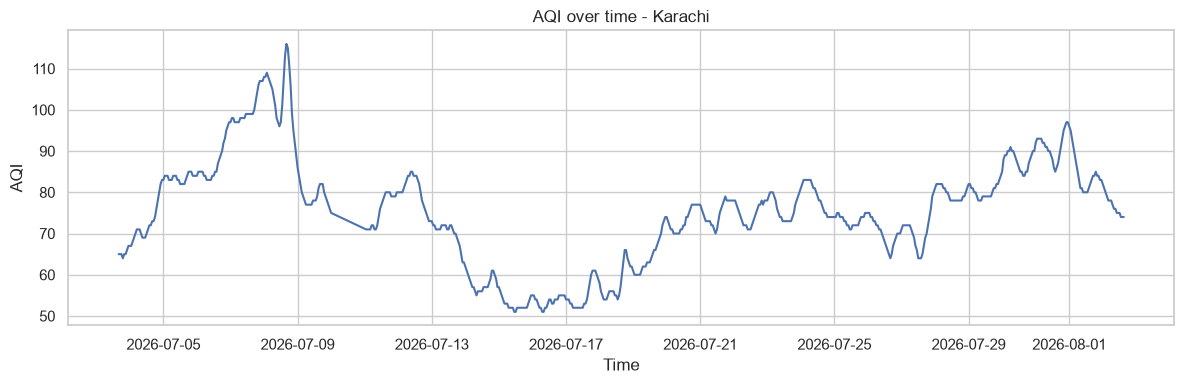

In [4]:
for city, group in df.groupby("city"):
    plt.figure(figsize=(12, 4))
    plt.plot(group["timestamp"], group["aqi"])
    plt.title(f"AQI over time - {city}")
    plt.xlabel("Time")
    plt.ylabel("AQI")
    plt.tight_layout()
    plt.show()

## AQI distribution

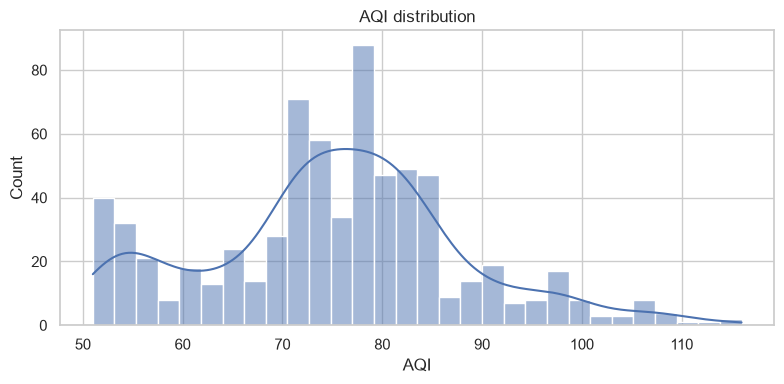

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["aqi"].dropna(), bins=30, kde=True)
plt.title("AQI distribution")
plt.xlabel("AQI")
plt.tight_layout()
plt.show()

## Hourly and day-of-week patterns

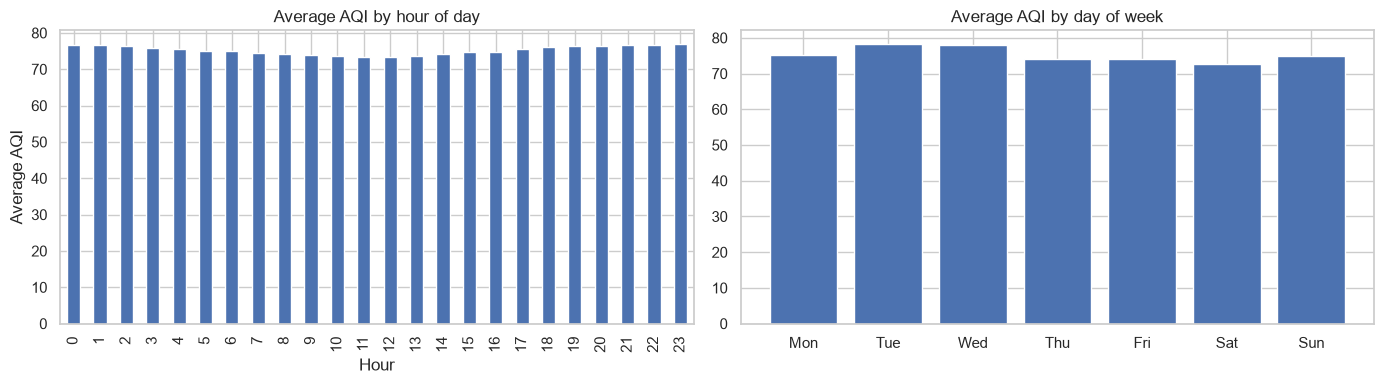

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby("hour")["aqi"].mean().plot(kind="bar", ax=axes[0], title="Average AQI by hour of day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Average AQI")

day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
avg_by_dow = df.groupby("day_of_week")["aqi"].mean()
axes[1].bar([day_names[i] for i in avg_by_dow.index], avg_by_dow.values)
axes[1].set_title("Average AQI by day of week")

plt.tight_layout()
plt.show()

## Correlations between pollutants/weather and AQI

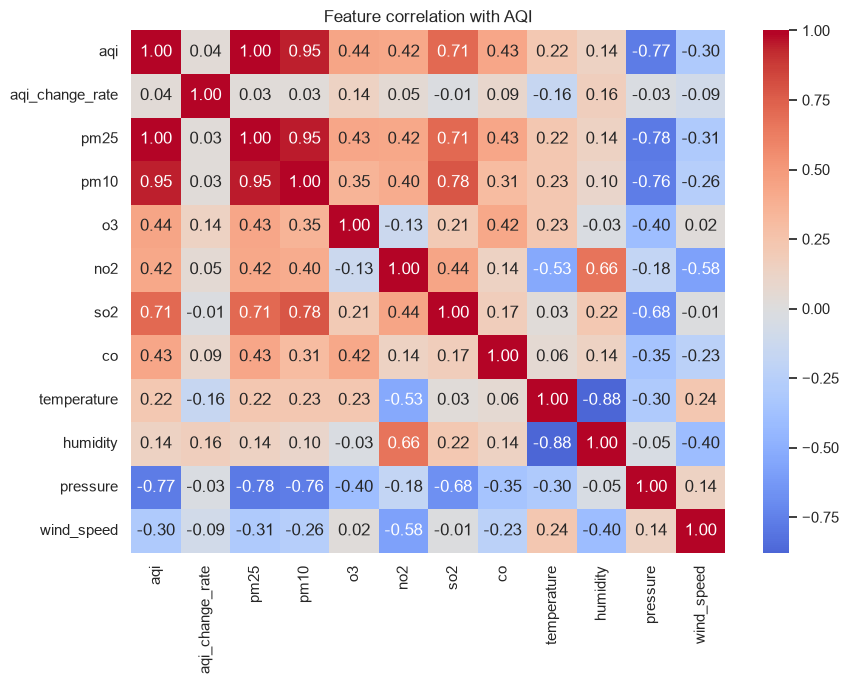

In [7]:
numeric_cols = [
    "aqi", "aqi_change_rate", "pm25", "pm10", "o3", "no2", "so2", "co",
    "temperature", "humidity", "pressure", "wind_speed",
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation with AQI")
plt.tight_layout()
plt.show()